Saving 4.jpg to 4.jpg


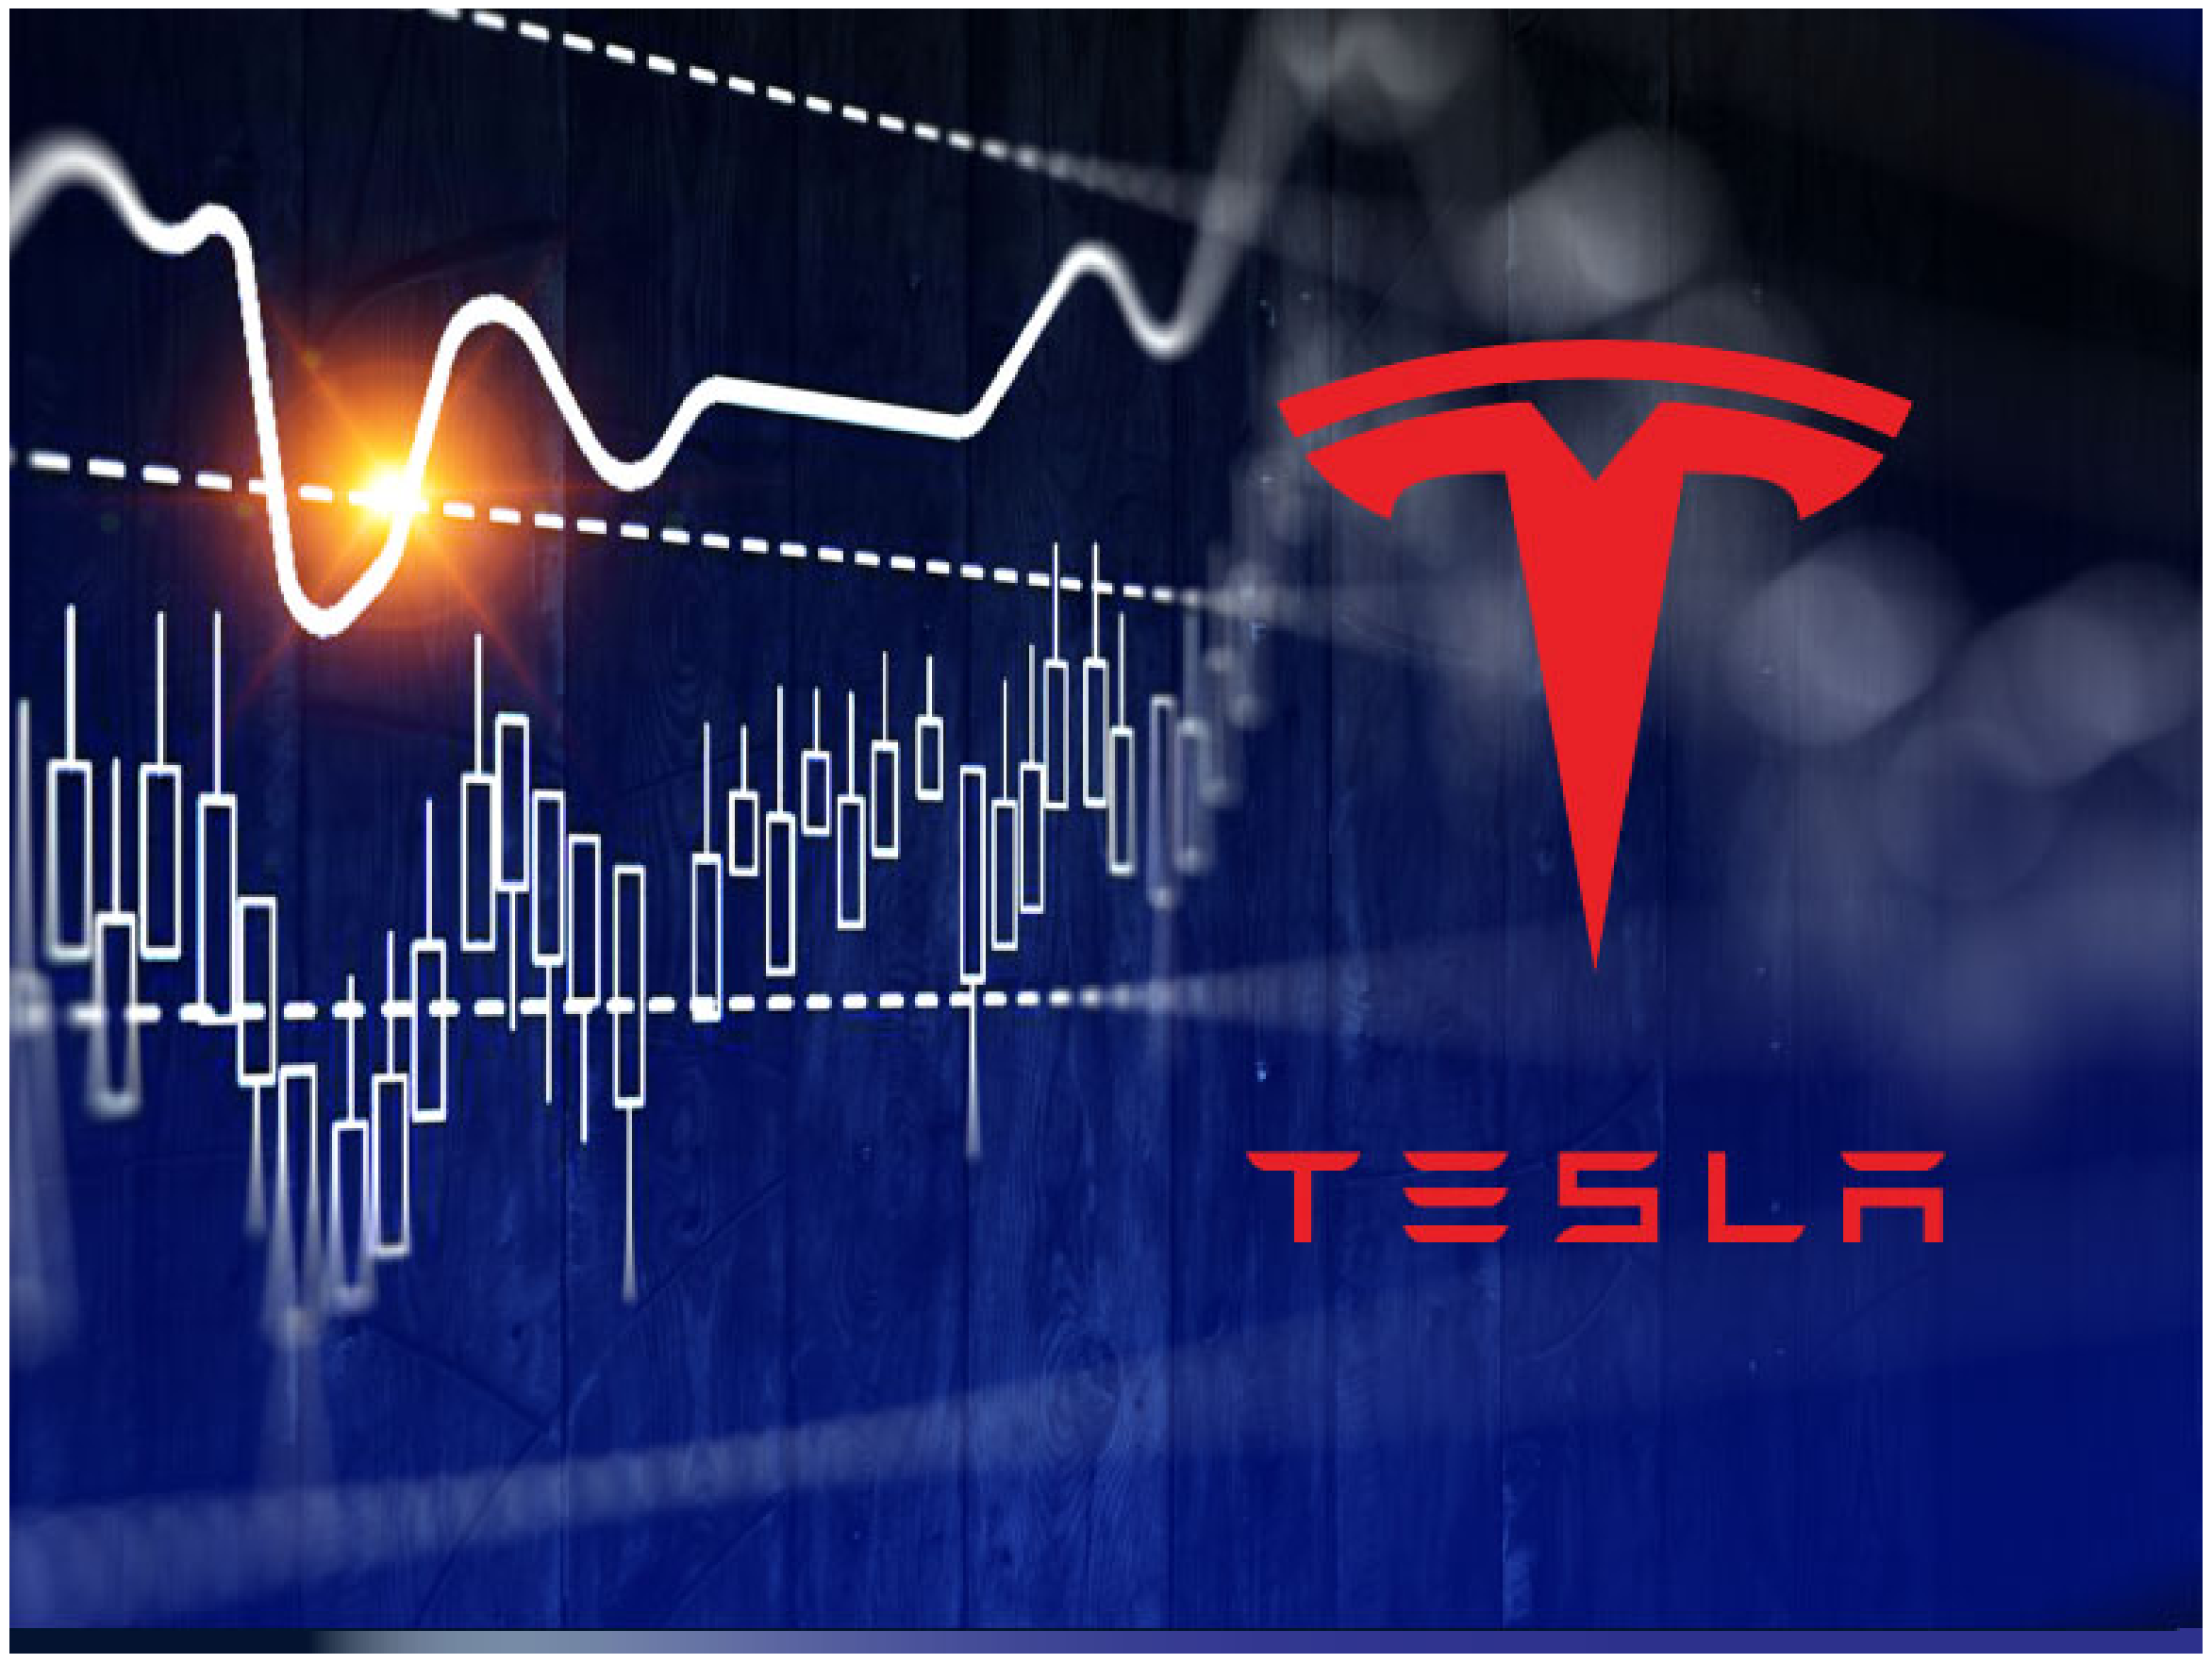

In [110]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

# ارفع الصورة
uploaded = files.upload()  # هيطلعلك زرار تختار منه الصورة

# افتح الصورة (هنا ناخد أول ملف مرفوع)
for filename in uploaded.keys():
    img = Image.open(filename)
    plt.figure(figsize=(30, 30))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# Dataset: TESLA Stock Data (TSLA)
#  Source: https://www.kaggle.com/datasets/varpit94/tesla-stock-data-updated-till-28jun2021

#  Data Description:
# Historical data for Tesla (TSLA) stock listed on Nasdaq
# Time Period: From 2010 to June 28, 2021
# Number of Rows: ~2956 trading days
# Currency: US Dollar (USD)

#  Columns:
# - Date: Trading day
# - Open: Opening price
# - High: Highest price during the day
# - Low: Lowest price during the day
# - Close: Closing price  (Used in Prediction)
# - Adj Close: Adjusted closing price
# - Volume: Trading volume

# Objective:
# Predicting Tesla's closing price using the LSTM model


# Data Loading & Exploration

In [54]:
pip install opendatasets

In [55]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/varpit94/tesla-stock-data-updated-till-28jun2021")

Skipping, found downloaded files in "./tesla-stock-data-updated-till-28jun2021" (use force=True to force download)


In [105]:
import pandas as pd
import numpy as np

import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go
import plotly.io as pio
import math
from datetime import datetime

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,confusion_matrix

import keras
from keras.layers import Dense, Dropout, LSTM
from keras.callbacks import EarlyStopping
from keras.models import Sequential

# Preprocessing

In [57]:
data=pd.read_csv("tesla-stock-data-updated-till-28jun2021/TSLA.csv")
data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500
1,2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500
2,2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000
3,2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000
4,2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500
...,...,...,...,...,...,...,...
2951,2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500
2952,2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200
2953,2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500
2954,2022-03-23,979.940002,1040.699951,976.400024,999.109985,999.109985,40225400


In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2956 non-null   object 
 1   Open       2956 non-null   float64
 2   High       2956 non-null   float64
 3   Low        2956 non-null   float64
 4   Close      2956 non-null   float64
 5   Adj Close  2956 non-null   float64
 6   Volume     2956 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 161.8+ KB


In [59]:
data.duplicated().sum()

np.int64(0)

In [60]:
data.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


# Visualization

In [61]:
open=go.Scatter(x=data.index,y=data["Open"],name="Open Price",mode='lines',line=dict(color="purple"))
close=go.Scatter(x=data.index,y=data["Close"],name="Close Price",mode='lines',line=dict(color="blue"))

layout=go.Layout(title="Tesla Stock Price")
fig=go.Figure(data=[open,close],layout=layout)
fig.show()

In [62]:
fig=px.line(data,x=data.index,y="High",title="Tesla Stock Price")
fig.show()

In [63]:
fig=px.line(data,x=data.index,y="Low",title="Tesla Stock Price")
fig.show()

In [64]:
high_avg = data["High"].mean()
low_avg = data["Low"].mean()

fig = go.Figure(data=[
    go.Bar(name='High Avg', x=['Tesla'], y=[high_avg], marker=dict(color='blue')),
    go.Bar(name='Low Avg', x=['Tesla'], y=[low_avg], marker=dict(color='purple'))
])

fig.update_layout(
    title="Average High vs Low Price",
    yaxis_title="Price (USD)",
    barmode='group'
)

fig.show()

In [65]:
volume=go.Scatter(x=data.index,y=data["Volume"],name="Volume",mode="lines")
layout=go.Layout(title="Tesla Stock Volume")
fig=go.Figure(data=[volume],layout=layout)
fig.show()

# Model Architecture


In [66]:
dataset = data[["Close"]]
dataset = pd.DataFrame(dataset)

In [67]:
data_2=dataset.values
data_2.shape

(2956, 1)

In [68]:
data_2

array([[   4.778   ],
       [   4.766   ],
       [   4.392   ],
       ...,
       [ 993.97998 ],
       [ 999.109985],
       [1013.919983]])

In [69]:
scaler=MinMaxScaler(feature_range=(0,1))
data_scaled=scaler.fit_transform(data_2)

In [70]:
train_size=int(len(data_2)*0.80)
test_size=len(data_2)-train_size
print(train_size,"/",test_size)

2364 / 592


In [71]:
train_data = data_scaled[:train_size, 0:1]
test_data = data_scaled[train_size-60:, 0:1]

# Why 60 ?
## In time series forecasting, the model often benefits from having access to a certain number of past data points to make predictions. For example, if you want to predict the value of a stock on a given day, you might use the previous 60 days of data to make that prediction

In [72]:
train_data.shape , test_data.shape

((2364, 1), (652, 1))

In [73]:
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

## Reshaping the input to 3D array [samples, time_steps, features]

In [74]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# LSTM Model

# Why LSTM?
## Long Short-Term Memory (LSTM) is an advanced type of neural network specifically designed to handle sequential data such as:

## Stock prices
## Text
## Audio


Saving 1722889824743.jpg to 1722889824743 (2).jpg


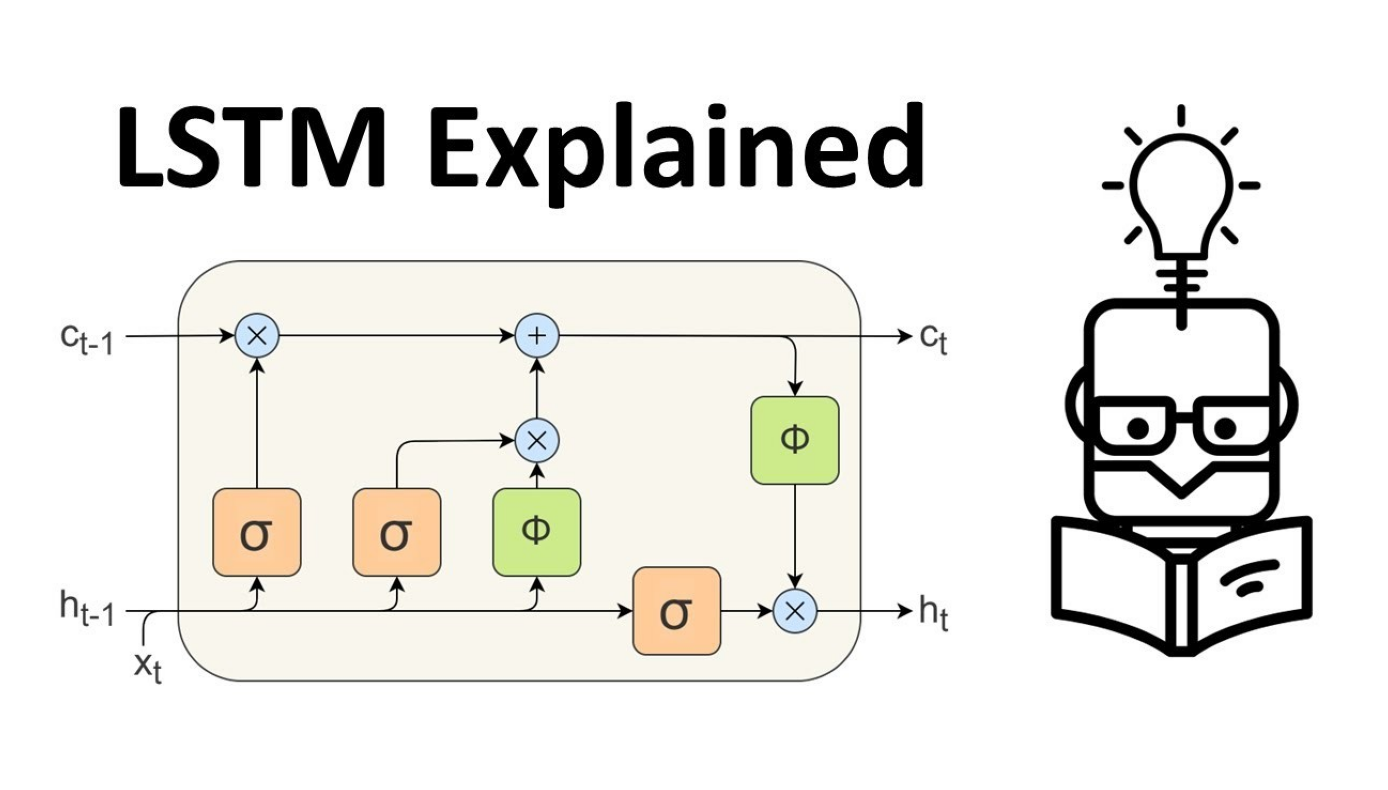

In [104]:
uploaded = files.upload()
for filename in uploaded.keys():
    img = Image.open(filename)
    plt.figure(figsize=(20, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [93]:
model=Sequential([
    LSTM(100,return_sequences=True,input_shape=(x_train.shape[1],1)),#بيرجع sequence كامل
    Dropout(0.2),

    LSTM(64, return_sequences=False),
    Dropout(0.2),

    Dense(32,activation='relu'),

    Dense(16,activation='relu'),

    Dense(1)#output
])
model.compile(optimizer='adam', loss='mse', metrics=['mean_absolute_error'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [94]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,665 (334.63 KB)

 Trainable params: 85,665 (334.63 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
history = model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="loss", patience=15, restore_best_weights=True)]
)

Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 1.0042e-04 - mean_absolute_error: 0.0065
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1078e-05 - mean_absolute_error: 0.0024
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1077e-05 - mean_absolute_error: 0.0024
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.6107e-06 - mean_absolute_error: 0.0023
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.4166e-06 - mean_absolute_error: 0.0023
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.1854e-06 - mean_absolute_error: 0.0021
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.3901e-06 - mean_absolute_error: 0.0021
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.7124e-06 - mean_absolute_error: 0.0020
Epoch 9/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.5813e-06 - mean_absolute_error: 0.0019
Epoch 10/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.3533e-06 - mean_absolute_error

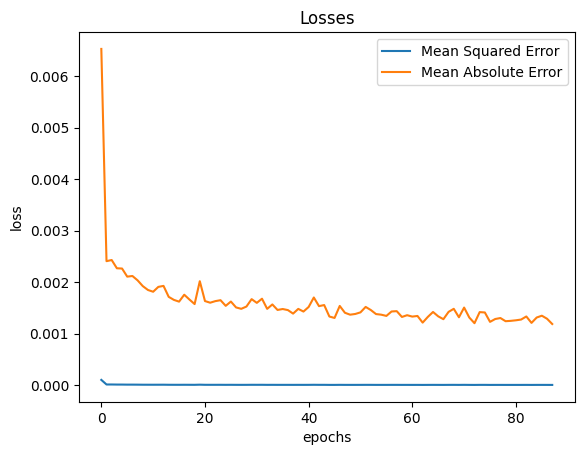

In [96]:
plt.plot(history.history["loss"])
plt.plot(history.history["mean_absolute_error"])
plt.title("Losses")
plt.legend(['Mean Squared Error','Mean Absolute Error'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

In [97]:
x_test = []
y_test = []

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])
    y_test.append(test_data[i, 0])
x_test = np.array(x_test)
y_test = np.array(y_test)

In [98]:
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [99]:
predictions = model.predict(x_test)


predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

#  RMSE
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("RMSE:", round(rmse, 2))

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
RMSE: 144.59


In [100]:
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 18.70%


In [103]:
model.save_weights("stock_model.weights.h5")